In [17]:
from datasets import load_dataset
from transformers import (
    Qwen3VLForConditionalGeneration,
    AutoProcessor,
    get_scheduler,
    TrainingArguments,
    Trainer,
    BitsAndBytesConfig,
    TextStreamer
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from typing import List, Dict, Any
import torch
from PIL import Image

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Fine-tuning example (only if needed on very domain-specific visual or textual patterns)

In [4]:
dataset = load_dataset("merve/vqav2-small", split="validation[:100]")

README.md:   0%|          | 0.00/403 [00:00<?, ?B/s]

data/validation-00000-of-00007.parquet:   0%|          | 0.00/484M [00:00<?, ?B/s]

data/validation-00001-of-00007.parquet:   0%|          | 0.00/486M [00:00<?, ?B/s]

data/validation-00002-of-00007.parquet:   0%|          | 0.00/483M [00:00<?, ?B/s]

data/validation-00003-of-00007.parquet:   0%|          | 0.00/486M [00:00<?, ?B/s]

data/validation-00004-of-00007.parquet:   0%|          | 0.00/475M [00:00<?, ?B/s]

data/validation-00005-of-00007.parquet:   0%|          | 0.00/484M [00:00<?, ?B/s]

data/validation-00006-of-00007.parquet:   0%|          | 0.00/479M [00:00<?, ?B/s]

Generating validation split:   0%|          | 0/21435 [00:00<?, ? examples/s]

In [5]:
dataset

Dataset({
    features: ['multiple_choice_answer', 'question', 'image'],
    num_rows: 100
})

In [6]:
split_dataset = dataset.train_test_split(test_size=0.2)

In [9]:
split_dataset = dataset["validation"].train_test_split(test_size=0.2)

ValueError: Column 'validation' doesn't exist.

In [7]:
split_dataset

DatasetDict({
    train: Dataset({
        features: ['multiple_choice_answer', 'question', 'image'],
        num_rows: 80
    })
    test: Dataset({
        features: ['multiple_choice_answer', 'question', 'image'],
        num_rows: 20
    })
})

In [9]:
train_dataset = split_dataset["train"]
test_dataset = split_dataset["test"]

In [11]:
def collate_fn(examples: List[Dict[str, Any]]) -> Dict[str, torch.Tensor]:
    """
    Collates a list of dataset examples into a batch compatible with Qwen-VL.
    Each example must contain:
        - "image": PIL.Image
        - "question": str
        - "multiple_choice_answer": str   (the gold answer)
    """
    texts: List[str] = []
    images_per_example: List[List[Image.Image]] = []   # list of [image] for each sample

    for ex in examples:
        image = ex["image"]               # already a PIL.Image
        question = ex["question"]
        answer   = ex["multiple_choice_answer"]

        # ------------------------------------------------------------------
        # 1. Build the chat template (training format: user → assistant)
        # ------------------------------------------------------------------
        messages = [
            {
                "role": "user",
                "content": [
                    {"type": "text",  "text": "Answer briefly."},
                    {"type": "image", "image": image},          # <-- real image
                    {"type": "text",  "text": question}
                ]
            },
            {
                "role": "assistant",
                "content": [
                    {"type": "text", "text": answer}
                ]
            }
        ]

        # `tokenize=False` → we get a plain string that contains the
        # placeholder <|image_pad|> where the image will be inserted later.
        text = processor.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=False
        )
        texts.append(text.strip())
        images_per_example.append([image])   # one image per sample

    # ------------------------------------------------------------------
    # 2. Let the processor do tokenisation + image embedding + padding
    # ------------------------------------------------------------------
    batch = processor(
        text=texts,
        images=images_per_example,   # list of list[Image]
        padding=True,
        return_tensors="pt"
    )

    # ------------------------------------------------------------------
    # 3. Build labels: ignore padding, **do NOT** ignore image tokens
    # ------------------------------------------------------------------
    labels = batch["input_ids"].clone()
    pad_id = processor.tokenizer.pad_token_id

    # Mask everything that is padding
    labels[labels == pad_id] = -100

    # **Important**: Qwen-VL inserts many <|image_pad|> tokens
    # (one per image patch).  Masking them would delete the image
    # signal from the loss → keep them **unmasked**.
    # If you *really* want to ignore them (e.g. for pure-text fine-tuning)
    # you can do:
    #   image_pad_id = processor.tokenizer.convert_tokens_to_ids("<|image_pad|>")
    #   labels[labels == image_pad_id] = -100
    # but for normal VQA you **should NOT** do that.

    batch["labels"] = labels
    return batch

In [13]:
model_id = "Qwen/Qwen3-VL-2B-Instruct"

# Use 4-bit quantization with NF4 dtype, which is often more stable
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,                 # Switch to 4-bit
    bnb_4bit_quant_type="nf4",         # Use NF4 quantization (recommended for stability)
    bnb_4bit_compute_dtype=torch.bfloat16, # Keep compute dtype as bfloat16 or try float16
    bnb_4bit_use_double_quant=True,    # Use double quantization for potentially better accuracy
)

model = Qwen3VLForConditionalGeneration.from_pretrained(
    model_id,
    dtype=torch.bfloat16,
    device_map="auto",
    quantization_config=quantization_config,
)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/4.26G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/269 [00:00<?, ?B/s]

In [16]:
model = prepare_model_for_kbit_training(model)

In [12]:
peft_config = LoraConfig(
    r=32,                    # ↑ from 16 → more capacity
    lora_alpha=64,           # ↑ scale up
    target_modules=[
        "o_proj", "q_proj", "k_proj", "v_proj",   # attention
        "gate_proj", "up_proj", "down_proj"  # MLP (Feed-forward)
    ],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
)
model = get_peft_model(model, peft_config)

In [18]:
model.print_trainable_parameters()

trainable params: 34,865,152 || all params: 2,162,397,184 || trainable%: 1.6123


In [14]:
processor = AutoProcessor.from_pretrained(model_id)

preprocessor_config.json:   0%|          | 0.00/390 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

video_preprocessor_config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

In [20]:
training_args = TrainingArguments(
    output_dir="./qwen3-vl-vqav2",
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=8,
    num_train_epochs=1,
    learning_rate=1e-4,
    bf16=True, # Ensure mixed precision training uses bfloat16
    gradient_checkpointing=False, # Keep this False as it was set before
    optim="paged_adamw_8bit", # This optimizer works with 4-bit quantized models too
    logging_steps=10,
    # eval_strategy="steps",
    # eval_steps=250,
    # save_strategy="steps",
    # save_steps=250,
    # save_total_limit=2,
    # load_best_model_at_end=True,
    # metric_for_best_model="accuracy", # Ensure this metric is correctly computed by your eval function
    # greater_is_better=True,
    remove_unused_columns=False,
    report_to="none",
    # dataloader_num_workers=2,
)
trainer = Trainer(
    model=model,
    args=training_args,
    data_collator=collate_fn,
    train_dataset=train_dataset,
    # eval_dataset=eval_dataset,
)

In [ ]:
trainer.train()

# Prompt Engineering

In [4]:
test_dataset = load_dataset("mychen76/invoices-and-receipts_ocr_v1", split="test")

README.md:   0%|          | 0.00/782 [00:00<?, ?B/s]

data/train-00000-of-00001-76ffc8319f74dd(…):   0%|          | 0.00/249M [00:00<?, ?B/s]

data/test-00000-of-00001-af2d92d1cee2851(…):   0%|          | 0.00/18.8M [00:00<?, ?B/s]

data/valid-00000-of-00001-894b4e1f736b57(…):   0%|          | 0.00/14.1M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2043 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/125 [00:00<?, ? examples/s]

Generating valid split:   0%|          | 0/70 [00:00<?, ? examples/s]

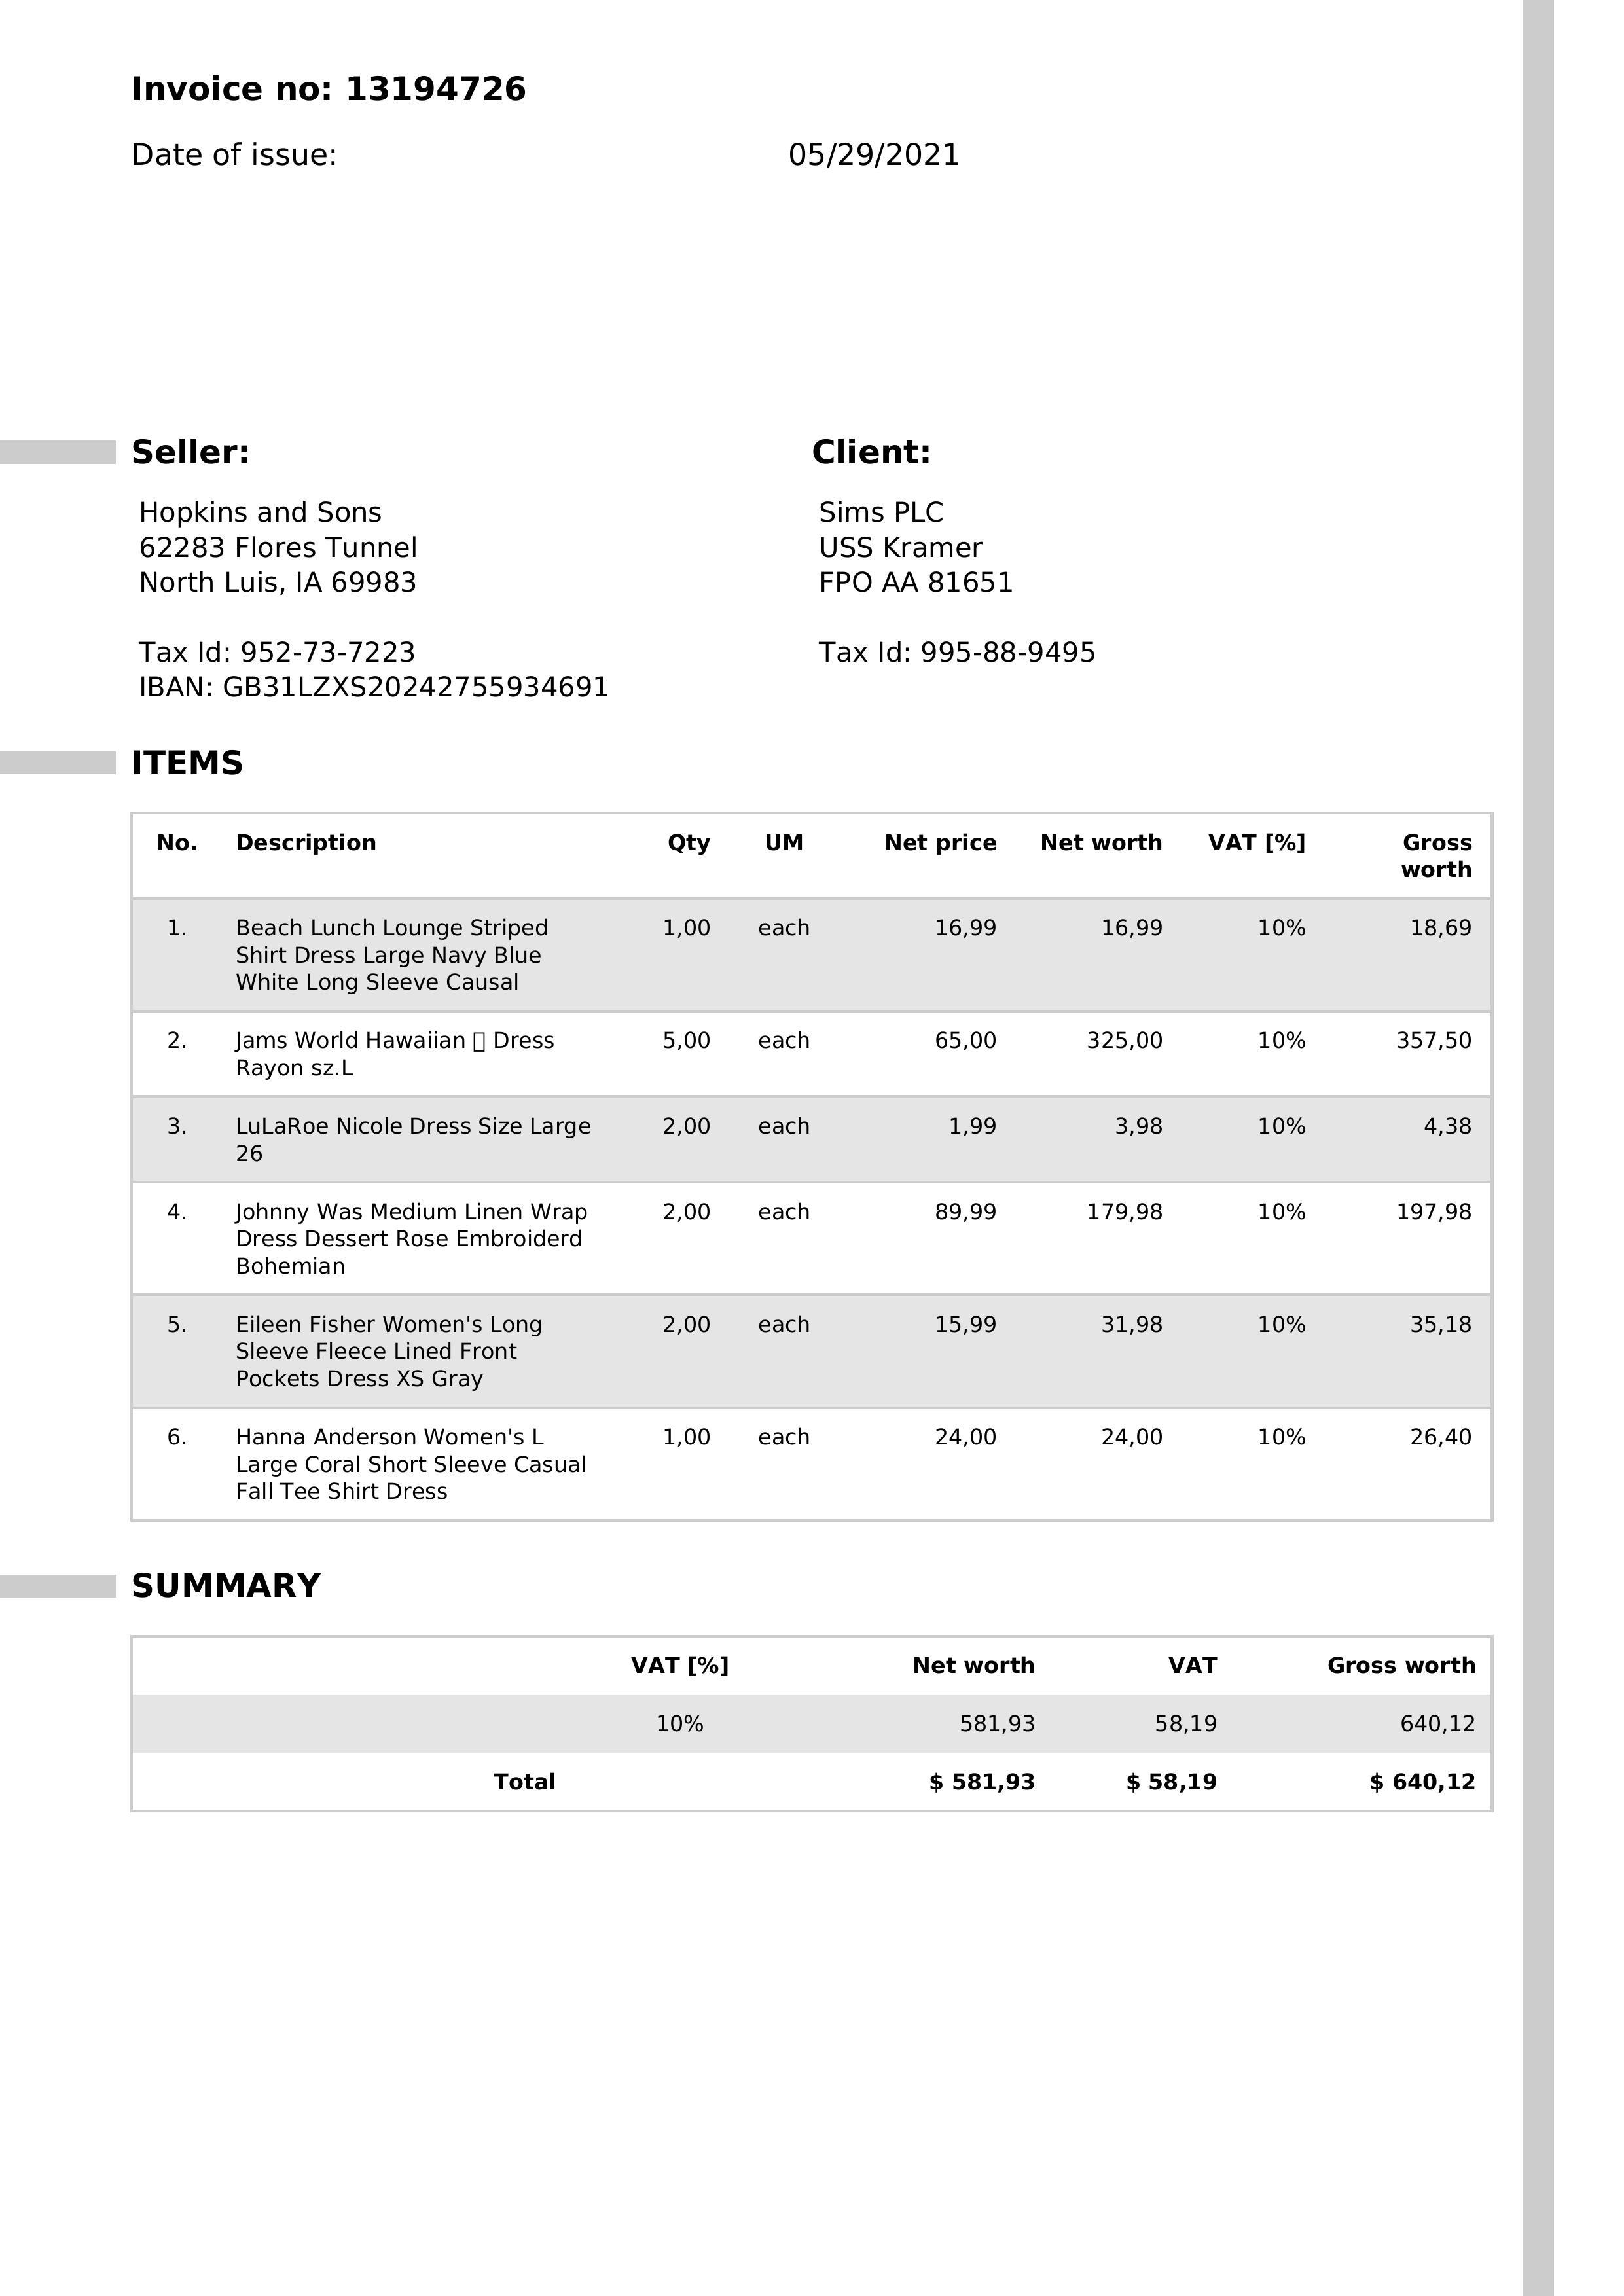

In [56]:
image = test_dataset[1]["image"]
image

In [57]:
MAX_SIZE = 512
image.thumbnail((MAX_SIZE, MAX_SIZE), Image.Resampling.LANCZOS)

In [58]:
image.size

(362, 512)

In [71]:
system_prompts = {
    "ocr_mode":
    """You are a precise OCR engine. 
Your goal is to transcribe every word visible in the image exactly as written, 
preserving line order and spacing when possible. 
Do not interpret, summarize, or infer missing text. 
Do not translate or correct typos. 
If part of the image is unreadable, mark it as [UNREADABLE]. 
Output plain text only.""",
    "structured_mode":
    """You are an assistant that converts receipts into structured JSON.
Return a JSON object with the following fields:
{
  "store_name": "",
  "date": "",
  "items": [
    {"name": "", "quantity": "", "price": ""}
  ],
  "subtotal": "",
  "tax": "",
  "total": ""
}

Do not summarize, abbreviate, or omit text.
Include all product lines in full as they appear on the receipt.
If a value is missing, use null. Do not add extra commentary.
Ensure the JSON has exactly the same number of items as in the receipt text.""",
}

In [73]:
# Prepare the messages list
messages = [
    {
        "role": "system",
        "content": system_prompts["structured_mode"]
    },
    {
        "role": "user",
        "content": [
            {"type": "image"},
            # {"type": "text", "text": "Describe this image."}
        ]
    }
]

# Apply the chat template AND tokenize it, also preparing for image processing
# This call should generate the correct input_ids, attention_mask, etc., AND handle image placeholders.
# Pass the messages list and the images list separately to the main processor call.
# The processor for Qwen3-VL likely expects this combined call.
# Apply the template to get the text prompt string
text_prompt = processor.apply_chat_template(
    messages,
    tokenize=False, # Get the string first
    add_generation_prompt=True,
)
print(f"Formatted text prompt from template: {text_prompt}")

# Now process the text prompt string and the image together
inputs = processor(
    text=text_prompt,
    images=image,
    return_tensors="pt",
    padding=True,
)

inputs = inputs.to(device)
inputs.pop("token_type_ids", None)

# --- Perform Inference ---
model.eval()
with torch.no_grad():
    generated_ids = model.generate(
        **inputs,
        max_new_tokens=512,
        do_sample=False,
        pad_token_id=processor.tokenizer.eos_token_id,
    )

# --- Decode Output ---
generated_ids_trimmed = [
    out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs['input_ids'], generated_ids)
]
output_text = processor.batch_decode(
    generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
)[0]

print(f"Generated Text: {output_text}")

Formatted text prompt from template: <|im_start|>system
You are an assistant that converts receipts into structured JSON.
Return a JSON object with the following fields:
{
  "store_name": "",
  "date": "",
  "items": [
    {"name": "", "quantity": "", "price": ""}
  ],
  "subtotal": "",
  "tax": "",
  "total": ""
}

Do not summarize, abbreviate, or omit text.
Include all product lines in full as they appear on the receipt.
If a value is missing, use null. Do not add extra commentary.<|im_end|>
<|im_start|>user
<|vision_start|><|image_pad|><|vision_end|><|im_end|>
<|im_start|>assistant

Generated Text: ```json
{
  "store_name": "Hopkins and Sons",
  "date": "05/29/2021",
  "items": [
    {
      "name": "Beach Lunch Lounge Striped Shirt",
      "quantity": "1",
      "price": "16.99"
    },
    {
      "name": "jams world Hawaiiian □ Dress",
      "quantity": "5.00",
      "price": "19.99"
    },
    {
      "name": "Lulu! Nicole Dress Size Large",
      "quantity": "2.00",
      "price